# Train Helmet & Vest Detection

Notebook ini training YOLO26m buat deteksi PPE (Personal Protective Equipment) di lokasi konstruksi. Total 5 kelas:

- `0 = helmet` — orang pakai helm
- `1 = no-helmet` — orang tanpa helm
- `2 = no-vest` — orang tanpa rompi
- `3 = person` — bbox orang umum
- `4 = vest` — orang pakai rompi

**Dataset asal:** `research/datasets/raw/helmet_and_vest/` — sudah ke-split jadi train/valid/test sama Roboflow.

**Catatan dataset:** `data.yaml` bawaan Roboflow punya path relatif yang broken (`../train/images`). Notebook ini bikin `data.yaml` versi fixed di `datasets/processed/helmet_and_vest/` yang nge-reuse images dari `raw/` via field `path:`. Nggak ada image yang di-copy — cuma 1 file kecil.

**Output:** `best.pt` di `research/runs/detect/helmet_and_vest_yolo26m/weights/`. Habis ini bisa di-register di [registry.py](../../../src/cctv_insight_ai/models/registry.py).

## Alur

1. Setup
2. Bikin data.yaml fixed
3. Cek dataset
4. Training
5. Load run terakhir
6. Evaluasi
7. Visualisasi (training curves, per-class, confusion matrix, sample prediksi)

In [1]:
%matplotlib inline

from __future__ import annotations

import contextlib
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image
from ultralytics import YOLO

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]
AI_DIR       = NOTEBOOK_DIR.parents[2]

RAW_DATASET_DIR  = RESEARCH_DIR / "datasets" / "raw" / "helmet_and_vest"
PROC_DATASET_DIR = RESEARCH_DIR / "datasets" / "processed" / "helmet_and_vest"
DATA_YAML        = PROC_DATASET_DIR / "data.yaml"
BASE_MODEL       = AI_DIR / "models" / "yolo26m.pt"

RUNS_DIR      = RESEARCH_DIR / "runs" / "detect"
ARTIFACTS_DIR = RESEARCH_DIR / "artifacts" / "helmet_and_vest"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME    = "helmet_and_vest_yolo26m"
SEED        = 42
CLASS_NAMES = ["helmet", "no-helmet", "no-vest", "person", "vest"]

for p in [RAW_DATASET_DIR, BASE_MODEL]:
    if not p.exists():
        raise FileNotFoundError(f"Nggak ketemu: {p}")
print("Raw dataset:", RAW_DATASET_DIR)
print("Processed data.yaml (target):", DATA_YAML)
print("Base model:", BASE_MODEL)

Raw dataset: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\raw\helmet_and_vest
Processed data.yaml (target): c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\processed\helmet_and_vest\data.yaml
Base model: c:\Users\istd.magang125\Documents\cctv-insight\ai\models\yolo26m.pt


## Bikin data.yaml Fixed

Tulis `data.yaml` baru di `processed/helmet_and_vest/` yang ngarah balik ke folder `raw/` via field `path:`. Idempotent — kalau udah ada, skip.

Set `OVERWRITE_YAML = True` kalau perlu rewrite (jarang).

In [ ]:
OVERWRITE_YAML = False


def build_data_yaml() -> None:
    if DATA_YAML.exists() and not OVERWRITE_YAML:
        print("data.yaml udah ada, skip:", DATA_YAML)
        return
    cfg = {
        "path":  str(RAW_DATASET_DIR.resolve()),
        "train": "train/images",
        "val":   "valid/images",
        "test":  "test/images",
        "nc":    len(CLASS_NAMES),
        "names": CLASS_NAMES,
    }
    PROC_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    DATA_YAML.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding="utf-8")
    print("data.yaml jadi:", DATA_YAML)


build_data_yaml()

data.yaml jadi: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\processed\helmet_and_vest\data.yaml


## Cek Dataset

Lihat distribusi label per kelas per split. Kelas yang minoritas berat sering jadi sumber recall jelek nanti.

In [3]:
def count_class_distribution(split: str) -> dict[int, int]:
    counts = {i: 0 for i in range(len(CLASS_NAMES))}
    labels_dir = RAW_DATASET_DIR / split / "labels"
    if not labels_dir.exists():
        return counts
    for lbl in labels_dir.glob("*.txt"):
        for line in lbl.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            cls = int(line.split()[0])
            counts[cls] = counts.get(cls, 0) + 1
    return counts


dist = {split: count_class_distribution(split) for split in ("train", "valid", "test")}
dist_df = pd.DataFrame(dist).fillna(0).astype(int)
dist_df.index = [CLASS_NAMES[i] for i in dist_df.index]
print("Kelas:", CLASS_NAMES)
print()
print(dist_df.to_string())

Kelas: ['helmet', 'no-helmet', 'no-vest', 'person', 'vest']

           train  valid  test
helmet      2116    232   195
no-helmet     94     11    24
no-vest      741     90    61
person      2362    241   214
vest        1073    141   129


## Training

Set `RUN_TRAINING = True` kalau emang mau training ulang. Default `False` biar nggak ke-trigger pas re-run notebook.

Default 50 epoch, patience 20 (auto-stop kalau val loss nggak turun selama 20 epoch). Ubah di `TRAIN_CFG` kalau perlu.

In [ ]:
RUN_TRAINING = False

TRAIN_CFG = {
    "epochs": 50,
    "imgsz": 640,
    "batch": 8,
    "workers": 4,
    "patience": 20,
    "seed": SEED,
    "project": str(RUNS_DIR),
    "name": RUN_NAME,
}


@contextlib.contextmanager
def _cwd(path):
    prev = os.getcwd()
    os.chdir(str(path))
    try:
        yield
    finally:
        os.chdir(prev)


if RUN_TRAINING:
    with _cwd(AI_DIR / "models"):
        model = YOLO(str(BASE_MODEL))
        result = model.train(data=str(DATA_YAML), **TRAIN_CFG)
    print("Training kelar:", result.save_dir)
else:
    print("Training di-skip. Set RUN_TRAINING=True kalau mau training ulang.")

New https://pypi.org/project/ultralytics/8.4.46 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.38  Python-3.14.3 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\processed\helmet_and_vest\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=30

## Load Run Terakhir

Cari folder run paling baru yang prefix-nya `helmet_and_vest_yolo26m`, ambil `best.pt`-nya buat di-eval.

In [5]:
def find_latest_run(prefix: str) -> Path:
    candidates = [
        d for d in RUNS_DIR.glob(f"{prefix}*")
        if d.is_dir() and (d / "weights" / "best.pt").exists()
    ]
    if not candidates:
        raise FileNotFoundError(f"Belum ada run dengan prefix '{prefix}' di {RUNS_DIR}")
    return max(candidates, key=lambda d: d.stat().st_mtime)


run_dir     = find_latest_run(RUN_NAME)
best_pt     = run_dir / "weights" / "best.pt"
results_csv = run_dir / "results.csv"
eval_model  = YOLO(str(best_pt))

print("Run dir:", run_dir)
print("Best weights:", best_pt)
print("Kelas:", eval_model.names)

Run dir: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\helmet_and_vest_yolo26m
Best weights: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\helmet_and_vest_yolo26m\weights\best.pt
Kelas: {0: 'helmet', 1: 'no-helmet', 2: 'no-vest', 3: 'person', 4: 'vest'}


## Evaluasi

Run `model.val()` di split valid. Yang dilihat: mAP50 (lenient), mAP50-95 (strict), Precision (false positive control), Recall (false negative control).

In [6]:
val = eval_model.val(data=str(DATA_YAML), imgsz=640, conf=0.25, verbose=False)

metrics = {
    "mAP50":     round(float(val.box.map50), 3),
    "mAP50-95":  round(float(val.box.map),   3),
    "Precision": round(float(val.box.mp),    3),
    "Recall":    round(float(val.box.mr),    3),
}
print("Metrik agregat:")
print(pd.DataFrame([metrics]).to_string(index=False))

Ultralytics 8.4.38  Python-3.14.3 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26m summary (fused): 132 layers, 20,353,307 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 516.1157.2 MB/s, size: 40.2 KB)
val: Scanning C:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\raw\helmet_and_vest\valid\labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 41.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.0it/s 4.0s0.3ss
                   all        119        715      0.874      0.779      0.762      0.447
Speed: 1.3ms preprocess, 16.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\istd.magang125\Documents\backend\runs\detect\val23
Metrik agregat:
 mAP50  mAP50-95  Precision  Recall
 0.762     0.447      0.874   0.779


## Visualisasi

Empat hal yang paling kepake buat liat performa:

1. **Training curves** — apakah training konvergen, atau masih bisa lebih baik kalau lanjut.
2. **Per-class metrics** — kelas mana yang lemah. Kelas `no-helmet` / `no-vest` biasanya lebih sulit karena minoritas.
3. **Confusion matrix** — kelas mana yang sering ke-tukar (paling sering: `helmet` ↔ `no-helmet`, `vest` ↔ `no-vest`).
4. **Sample prediksi** — sanity check di image asli.

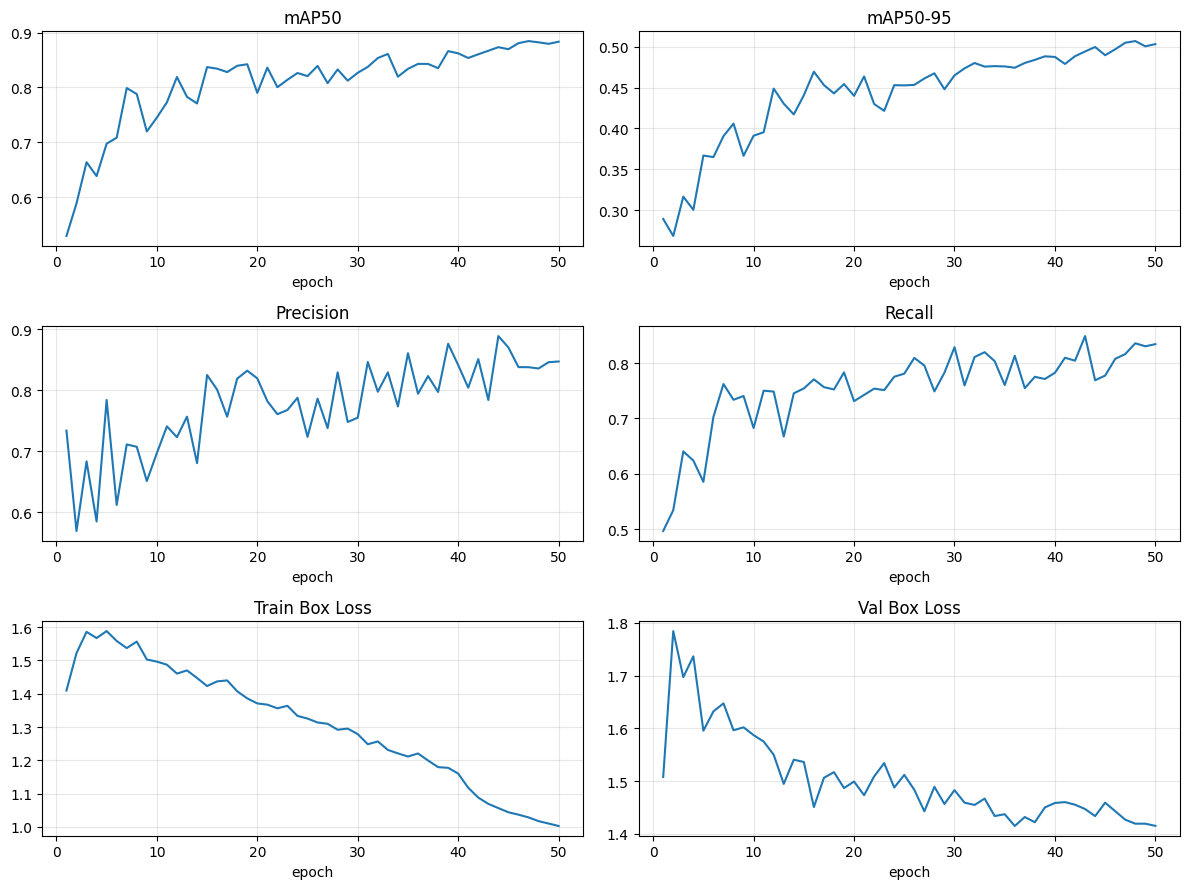

In [7]:
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

curves = [
    ("metrics/mAP50(B)",     "mAP50"),
    ("metrics/mAP50-95(B)",  "mAP50-95"),
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)",    "Recall"),
    ("train/box_loss",       "Train Box Loss"),
    ("val/box_loss",         "Val Box Loss"),
]
available = [(c, label) for c, label in curves if c in df.columns]
rows_n = (len(available) + 1) // 2
fig, axes = plt.subplots(rows_n, 2, figsize=(12, 3 * rows_n))
axes = axes.flatten()
for ax, (col, label) in zip(axes, available):
    ax.plot(df["epoch"], df[col])
    ax.set_title(label)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
for ax in axes[len(available):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Per-class metrics:
    class  Precision  Recall  mAP50  mAP50-95
   helmet      0.892   0.909  0.900     0.511
no-helmet      0.778   0.545  0.519     0.279
  no-vest      0.830   0.700  0.662     0.343
   person      0.937   0.946  0.928     0.643
     vest      0.935   0.794  0.799     0.460


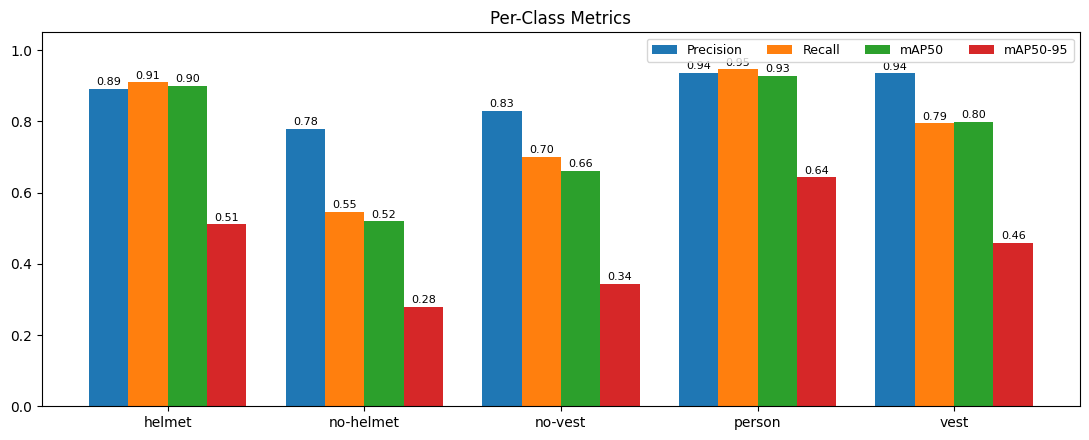

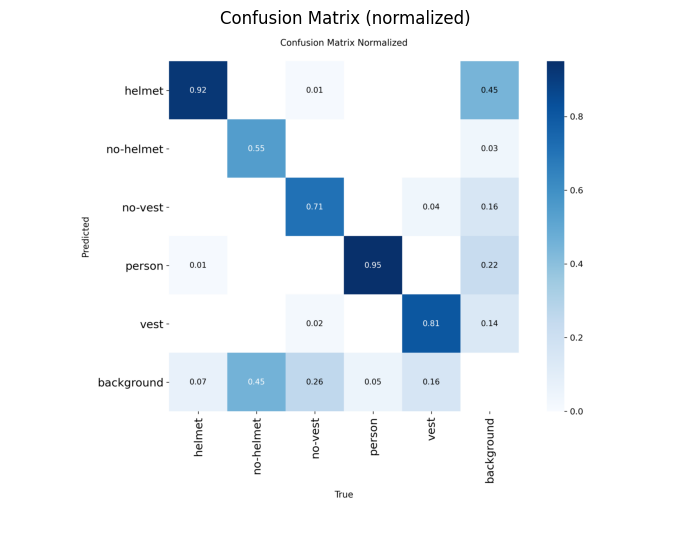

In [8]:
class_indices = val.box.ap_class_index.astype(int).tolist()
per_class = []
for i, ci in enumerate(class_indices):
    p, r, ap50, ap = val.box.class_result(i)
    per_class.append({
        "class":     val.names[ci],
        "Precision": float(p),
        "Recall":    float(r),
        "mAP50":     float(ap50),
        "mAP50-95":  float(ap),
    })
per_class_df = pd.DataFrame(per_class)
print("Per-class metrics:")
print(per_class_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
to_plot = ["Precision", "Recall", "mAP50", "mAP50-95"]
x = list(range(len(per_class_df)))
width = 0.2
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for j, m in enumerate(to_plot):
    offset = (j - 1.5) * width
    bars = ax.bar([xi + offset for xi in x], per_class_df[m], width, label=m, color=colors[j])
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(per_class_df["class"])
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class Metrics")
ax.legend(loc="upper right", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

cm_path = Path(val.save_dir) / "confusion_matrix_normalized.png"
if cm_path.exists():
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(Image.open(cm_path))
    ax.set_title("Confusion Matrix (normalized)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrix nggak ketemu di:", cm_path)

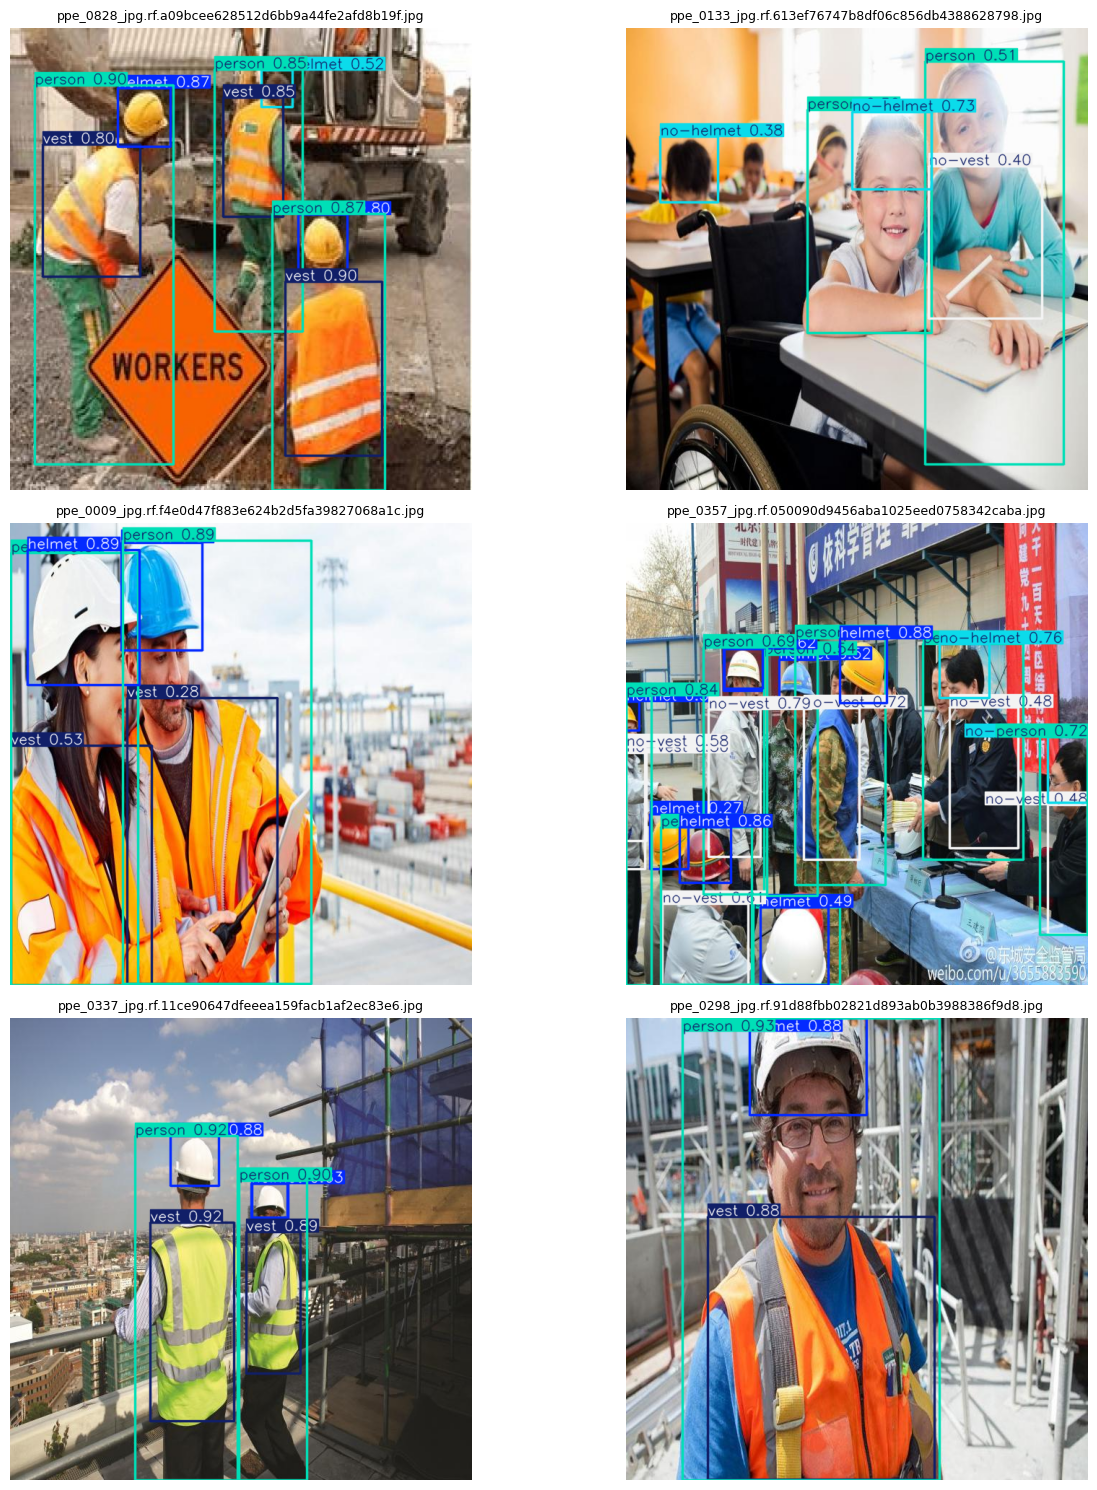

In [9]:
N_SAMPLES = 6
test_dir = RAW_DATASET_DIR / "test" / "images"
test_images: list[Path] = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    test_images.extend(sorted(test_dir.glob(ext)))

samples = random.Random(SEED).sample(test_images, min(N_SAMPLES, len(test_images)))

cols = 2
rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(14, 5 * rows_n))
axes = axes.flatten()
for ax, img_path in zip(axes, samples):
    r = eval_model.predict(str(img_path), conf=0.25, imgsz=640, verbose=False)[0]
    ax.imshow(r.plot()[..., ::-1])
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")
for ax in axes[len(samples):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Simpan Artifact

Persist hasil evaluasi ke `research/artifacts/helmet_and_vest/`:

- `eval_report.json` — config training/eval + metrik agregat + speed
- `per_class_metrics.csv` — Precision/Recall/mAP per kelas
- `class_distribution.csv` — distribusi label per split + total

Idempotent — bisa di-rerun kapan aja, file ke-overwrite.

In [ ]:
import json
import torch

speed = getattr(val, "speed", {}) or {}
preprocess_ms  = float(speed.get("preprocess", 0.0))
inference_ms   = float(speed.get("inference", 0.0))
postprocess_ms = float(speed.get("postprocess", 0.0))
total_ms       = preprocess_ms + inference_ms + postprocess_ms
fps            = (1000.0 / total_ms) if total_ms > 0 else 0.0

eval_report = {
    "model_key":   "helmet_and_vest",
    "base_weight": str(BASE_MODEL),
    "run_dir":     str(run_dir),
    "best_pt":     str(best_pt),
    "data_yaml":   str(DATA_YAML),
    "class_names": CLASS_NAMES,
    "seed":        SEED,
    "train_cfg":   TRAIN_CFG,
    "eval_cfg":    {"conf": 0.25, "imgsz": 640, "split": "val"},
    "device":      "cuda" if torch.cuda.is_available() else "cpu",
    "metrics": {
        "mAP50":     float(val.box.map50),
        "mAP50-95":  float(val.box.map),
        "precision": float(val.box.mp),
        "recall":    float(val.box.mr),
    },
    "speed_ms": {
        "preprocess":  preprocess_ms,
        "inference":   inference_ms,
        "postprocess": postprocess_ms,
        "total":       total_ms,
        "fps":         fps,
    },
}

eval_report_path = ARTIFACTS_DIR / "eval_report.json"
eval_report_path.write_text(json.dumps(eval_report, indent=2), encoding="utf-8")
print("Saved:", eval_report_path)

per_class_path = ARTIFACTS_DIR / "per_class_metrics.csv"
per_class_df.to_csv(per_class_path, index=False)
print("Saved:", per_class_path)

dist_to_save = dist_df.copy()
dist_to_save["total"] = dist_to_save.sum(axis=1)
dist_path = ARTIFACTS_DIR / "class_distribution.csv"
dist_to_save.to_csv(dist_path, index_label="class")
print("Saved:", dist_path)


## Catatan

Patokan kasar buat PPE detection (helmet & vest):

| mAP50 | Verdict |
|---|---|
| ≥ 0.85 | Bagus, siap deploy |
| 0.70 – 0.85 | Lumayan, bisa dipakai dengan post-processing tambahan |
| < 0.70 | Lemah, butuh tuning |

Hal yang sering muncul di dataset ini:

- Kelas `helmet` ↔ `no-helmet` sering ke-tukar di image yang helm-nya kecil / kepotong frame.
- Kelas `vest` warna nyolok lebih gampang dideteksi dibanding wajah-wajahan.
- Kelas `person` bisa overlap sama `helmet`/`vest` kalau bbox-nya nge-cover seluruh badan — wajar, dataset memang label dua-duanya.

Kalau hasilnya masih kurang:

- Naikin `epochs` (default 50, coba 100).
- Cek confusion matrix — kalau `no-helmet`/`no-vest` recall jelek, mungkin minoritas kelas perlu oversample atau class-weighted loss.
- Cek `args.yaml` di run dir buat liat augmentasi yang aktif.

Buat register ke service: tambah entry baru di [registry.py](../../../src/cctv_insight_ai/models/registry.py) dengan `task_classes=[0, 1, 2, 3, 4]`.